# Event-driven Aprop on streaming MNIST

Implementation of **Algorithm 1** (event-driven Aprop) in JAX + Equinox, plus a synchronous
backprop baseline for reference.

**Setup.** Time is a sequence of integer *event ticks*. Input $x_k$ arrives at tick
$\tau_k = k \cdot \texttt{hold\_steps}$ and its target $z_k$ at $\rho_k = \tau_k + \texttt{target\_delay}$.
Each layer keeps an activation trace $\hat a_{l-1}$, a backward-message trace $\hat m_{l+1\to l}$
and an error trace $\hat\delta_l$, and owns three clocks (forward-message, backward-message,
and the update clock $\mathcal{T}_l$). Messages are **latched**: a message sent at tick $t$ is read
by the neighbouring layer at tick $t+1$, so information travels exactly one layer per tick.
Nothing in the loop is a global forward/backward pass.

**Latency structure that follows from that.** With all message clocks at period 1:

| event | tick |
|---|---|
| $x_k$ reaches the output | $\tau_k + L - 1$ |
| target read, so `target_delay` should be $L$ | $\rho_k = \tau_k + L$ |
| the error from $e_k$ reaches layer $i$ | $\tau_k + 2L - 1 - i$ |

So layer $i$ holds *both* the activations of $x_k$ and the error of $x_k$ only at tick
$\tau_k + 2L - 1 - i$. The round trip is $2L-1$ ticks, which is the quantity the experiments below
are really about.

**Questions.** (1) Does it learn, and how does it compare to backprop? (2) How does it degrade
with depth? (3) How does it depend on how long each image is presented?

In [1]:
from dataclasses import dataclass
from typing import Dict, Sequence, Tuple, Union

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

print(jax.devices())

[CudaDevice(id=0)]


In [2]:
def load_mnist() -> Tuple[np.ndarray, np.ndarray, int, int]:
    """Load MNIST, group images by class.

    Returns:
        all_images: (num_classes, max_per_class, 28, 28) float32 [0, 1]
        samples_per_class: (num_classes,) int32
        num_classes: 10
        input_dim: 784
    """
    from torchvision import datasets

    ds = datasets.MNIST(root='/tmp/data', train=True, download=True)
    images = ds.data.numpy().astype(np.float32) / 255.0  # (60000, 28, 28)
    labels = ds.targets.numpy()
    num_classes = 10

    max_per_class = max(int(np.sum(labels == c)) for c in range(num_classes))
    all_images = np.zeros((num_classes, max_per_class, 28, 28), dtype=np.float32)
    samples_per_class = np.zeros(num_classes, dtype=np.int32)

    for c in range(num_classes):
        mask = labels == c
        class_images = images[mask]
        n = class_images.shape[0]
        all_images[c, :n] = class_images
        samples_per_class[c] = n

    return all_images, samples_per_class, num_classes, 784


class ShuffledMNISTStream:
    """CPU-side i.i.d. MNIST stream (baseline). Samples random digits each step."""

    def __init__(
        self,
        all_images: np.ndarray,
        samples_per_class: np.ndarray,
        num_classes: int,
        seed: int,
    ):
        self.all_images = all_images
        self.samples_per_class = samples_per_class
        self.num_classes = num_classes
        self.rng = np.random.default_rng(seed)

    def sample_batch(self, n_steps: int) -> Tuple[np.ndarray, np.ndarray]:
        """Sample n_steps of i.i.d. MNIST data.

        Returns:
            images: (n_steps, 784) float32
            labels: (n_steps,) int32
        """
        images = np.empty((n_steps, 784), dtype=np.float32)
        labels = np.empty(n_steps, dtype=np.int32)

        for i in range(n_steps):
            c = self.rng.integers(self.num_classes)
            n = self.samples_per_class[c]
            idx = self.rng.integers(n)
            images[i] = self.all_images[c, idx].reshape(784)
            labels[i] = c

        return images, labels


def make_mnist_stream(seed: int) -> ShuffledMNISTStream:
    all_images, samples_per_class, num_classes, input_dim = load_mnist()
    return ShuffledMNISTStream(all_images, samples_per_class, num_classes, seed)


In [3]:
def lecun_uniform(key, shape):
    """shape = (out, in); LeCun-uniform over fan_in."""
    limit = np.sqrt(3.0 / shape[1])
    return jax.random.uniform(key, shape, minval=-limit, maxval=limit)


class MLP(eqx.Module):
    """ReLU MLP with a linear output head. Weights/biases are kept as plain tuples so that
    Aprop can rebuild the module from per-layer outer products."""

    weights: Tuple[jax.Array, ...]
    biases: Tuple[jax.Array, ...]

    def __init__(self, dims: Sequence[int], key):
        keys = jax.random.split(key, len(dims) - 1)
        self.weights = tuple(lecun_uniform(k, (dims[i + 1], dims[i])) for i, k in enumerate(keys))
        self.biases = tuple(jnp.zeros(dims[i + 1]) for i in range(len(dims) - 1))

    @property
    def dims(self) -> Tuple[int, ...]:
        return (self.weights[0].shape[1],) + tuple(W.shape[0] for W in self.weights)

    def __call__(self, x):
        n = len(self.weights)
        for i, (W, b) in enumerate(zip(self.weights, self.biases)):
            x = W @ x + b
            if i < n - 1:
                x = jax.nn.relu(x)
        return x


def mlp_dims(n_layers: int, hidden_dim: int = 64, input_dim: int = 784, output_dim: int = 10):
    return [input_dim] + [hidden_dim] * (n_layers - 1) + [output_dim]

In [4]:
class ApropState(eqx.Module):
    """Per-layer traces and the messages latched on the wires.

    fwd[j], bwd[j]: message currently sitting on the wire between layer j-1 and layer j (dim dims[j]).
                    fwd[0] is the input message a_0^msg, bwd[L] is the output error e_k.
    a[i]: activation trace  hat{a}_{i}        feeding layer i   (dim dims[i])
    m[i]: backward message trace hat{m}_{i+1 -> i}              (dim dims[i+1])
    d[i]: error trace hat{delta}_i                              (dim dims[i+1])
    """

    fwd: Tuple[jax.Array, ...]
    bwd: Tuple[jax.Array, ...]
    a: Tuple[jax.Array, ...]
    m: Tuple[jax.Array, ...]
    d: Tuple[jax.Array, ...]


def init_state(dims: Sequence[int]) -> ApropState:
    L = len(dims) - 1
    return ApropState(
        fwd=tuple(jnp.zeros(d) for d in dims),
        bwd=tuple(jnp.zeros(d) for d in dims),
        a=tuple(jnp.zeros(dims[i]) for i in range(L)),
        m=tuple(jnp.zeros(dims[i + 1]) for i in range(L)),
        d=tuple(jnp.zeros(dims[i + 1]) for i in range(L)),
    )


IntOrTuple = Union[int, Tuple[int, ...]]


@dataclass(frozen=True)
class ApropConfig:
    """Periods/phases are per layer; pass an int to use the same value for every layer.
    A clock fires on ticks where `t % period == phase`."""

    lr: float = 0.01
    beta_a: float = 1.0          # activation trace rate
    beta_m: float = 1.0          # backward message trace rate
    beta_d: float = 1.0          # error trace rate
    fwd_period: IntOrTuple = 1   # forward message clock
    bwd_period: IntOrTuple = 1   # backward message clock
    upd_period: IntOrTuple = 1   # update clock T_l
    fwd_phase: IntOrTuple = 0
    bwd_phase: IntOrTuple = 0
    upd_phase: IntOrTuple = 0


def _expand(v: IntOrTuple, L: int) -> Tuple[int, ...]:
    return (int(v),) * L if isinstance(v, int) else tuple(v)


def _clock(t, period: int, phase: int):
    """True on ticks where this clock fires (a Python bool when it always fires, so XLA folds it)."""
    return True if period == 1 else (t % period) == phase


def _sel(on, new, old):
    return new if on is True else jnp.where(on, new, old)

In [5]:
def aprop_tick(model: MLP, state: ApropState, t, x, label, has_x, has_y, cfg: ApropConfig):
    """One event time t of Algorithm 1.

    Every read uses messages latched on earlier ticks, so a message travels exactly one layer
    per tick. Returns (model, state, per-layer grads, (loss, correct)); the loss/correct pair is
    only meaningful on ticks where has_y is True.
    """
    L = len(model.weights)
    fwd_p, fwd_ph = _expand(cfg.fwd_period, L), _expand(cfg.fwd_phase, L)
    bwd_p, bwd_ph = _expand(cfg.bwd_period, L), _expand(cfg.bwd_phase, L)
    upd_p, upd_ph = _expand(cfg.upd_period, L), _expand(cfg.upd_phase, L)

    # lines 4-6: a new input arrives -> set/update the input message a_0^msg
    read_fwd = list(state.fwd)
    read_fwd[0] = jnp.where(has_x, x, read_fwd[0])

    # lines 7-10: a delayed target arrives -> e_k from a_L(rho_k^-), then trace it into delta_L
    logits = state.fwd[L]                     # the output as of just before this tick
    log_p = jax.nn.log_softmax(logits)
    e = jnp.exp(log_p) - jax.nn.one_hot(label, logits.shape[0])   # softmax-CE output error
    loss = -log_p[label]
    correct = (jnp.argmax(logits) == label).astype(jnp.float32)

    read_bwd = list(state.bwd)
    read_bwd[L] = jnp.where(has_y, e, read_bwd[L])

    out_fwd, out_bwd = list(read_fwd), list(read_bwd)
    new_a, new_m, new_d = list(state.a), list(state.m), list(state.d)
    new_W, new_b, grads = [], [], []

    for i in range(L):
        W, b = model.weights[i], model.biases[i]

        # lines 11-14: forward message event
        f_on = _clock(t, fwd_p[i], fwd_ph[i])
        a_i = _sel(f_on, (1 - cfg.beta_a) * state.a[i] + cfg.beta_a * read_fwd[i], state.a[i])
        h_i = W @ a_i + b
        act_i = h_i if i == L - 1 else jax.nn.relu(h_i)
        out_fwd[i + 1] = _sel(f_on, act_i, read_fwd[i + 1])
        new_a[i] = a_i

        # lines 15-18: backward message event. The top layer's error trace is driven straight
        # from e_k (line 9), so it only moves on target events.
        if i == L - 1:
            b_on = has_y
            m_i = state.m[i]
            d_i = jnp.where(b_on, (1 - cfg.beta_d) * state.d[i] + cfg.beta_d * read_bwd[L], state.d[i])
        else:
            b_on = _clock(t, bwd_p[i], bwd_ph[i])
            m_i = _sel(b_on, (1 - cfg.beta_m) * state.m[i] + cfg.beta_m * read_bwd[i + 1], state.m[i])
            d_inst = m_i * (h_i > 0).astype(h_i.dtype)          # elementwise phi'(h_i)
            d_i = _sel(b_on, (1 - cfg.beta_d) * state.d[i] + cfg.beta_d * d_inst, state.d[i])
        new_m[i], new_d[i] = m_i, d_i
        if i > 0:                                                # layer 0 has nobody to send to
            out_bwd[i] = _sel(b_on, W.T @ d_i, read_bwd[i])

        # lines 19-22: update clock ticks -> g_l = delta_l a_{l-1}^T
        gW, gb = jnp.outer(d_i, a_i), d_i
        grads.append((gW, gb))
        u_on = _clock(t, upd_p[i], upd_ph[i])
        alpha = cfg.lr if u_on is True else cfg.lr * u_on.astype(gW.dtype)
        new_W.append(W - alpha * gW)
        new_b.append(b - alpha * gb)

    model = eqx.tree_at(lambda m: list(m.weights) + list(m.biases), model, new_W + new_b)
    state = ApropState(tuple(out_fwd), tuple(out_bwd), tuple(new_a), tuple(new_m), tuple(new_d))
    return model, state, grads, (loss, correct)

In [6]:
def build_schedule(n_images: int, hold_steps: int, target_delay: int) -> Dict[str, np.ndarray]:
    """Event schedule: x_k arrives at tau_k = k * hold_steps, target z_k at rho_k = tau_k + delay."""
    tau = np.arange(n_images) * hold_steps
    rho = tau + target_delay
    T = int(rho[-1]) + 1
    img_idx = np.full(T, -1, np.int32)
    tgt_idx = np.full(T, -1, np.int32)
    img_idx[tau] = np.arange(n_images)
    tgt_idx[rho] = np.arange(n_images)
    return dict(
        t=np.arange(T, dtype=np.int32),
        img_idx=np.maximum(img_idx, 0),
        has_x=(img_idx >= 0),
        tgt_idx=np.maximum(tgt_idx, 0),
        has_y=(tgt_idx >= 0),
    )


@eqx.filter_jit
def _aprop_scan(model, imgs, labs, t, img_idx, has_x, tgt_idx, has_y, cfg):
    state = init_state(model.dims)

    def body(carry, ev):
        model, state = carry
        t, idx, has_x, tgt, has_y = ev
        model, state, _, metrics = aprop_tick(
            model, state, t, imgs[idx], labs[tgt], has_x, has_y, cfg)
        return (model, state), metrics

    return jax.lax.scan(body, (model, state), (t, img_idx, has_x, tgt_idx, has_y))


def run_aprop(model: MLP, images, labels, sched, cfg: ApropConfig):
    """Run the event loop. Returns the final model and one prediction per image (taken at the
    tick the target arrives, i.e. before that image's error has been used)."""
    (model, _), (loss, correct) = _aprop_scan(
        model, jnp.asarray(images), jnp.asarray(labels), sched['t'], sched['img_idx'],
        sched['has_x'], sched['tgt_idx'], sched['has_y'], cfg)
    keep = sched['has_y']                       # exactly one target event per image, in order
    return model, dict(loss=np.asarray(loss)[keep], correct=np.asarray(correct)[keep])


@eqx.filter_jit
def run_bp(model: MLP, images, labels, lr: float, repeat: int = 1):
    """Synchronous streaming backprop baseline: predict, then SGD on that one sample.
    `repeat` presents each image `repeat` times in a row (to compute-match a long Aprop hold)."""
    imgs, labs = jnp.asarray(images), jnp.asarray(labels)
    if repeat > 1:
        imgs, labs = jnp.repeat(imgs, repeat, axis=0), jnp.repeat(labs, repeat, axis=0)

    def loss_fn(model, x, y):
        logits = model(x)
        return -jax.nn.log_softmax(logits)[y], logits

    def body(model, xy):
        x, y = xy
        (loss, logits), grads = eqx.filter_value_and_grad(loss_fn, has_aux=True)(model, x, y)
        model = jax.tree.map(lambda p, g: p - lr * g, model, grads)
        return model, (loss, (jnp.argmax(logits) == y).astype(jnp.float32))

    model, (loss, correct) = jax.lax.scan(body, model, (imgs, labs))
    if repeat > 1:                              # keep the first (pre-update) prediction per image
        loss, correct = loss[::repeat], correct[::repeat]
    return model, dict(loss=loss, correct=correct)


def aligned_update_clock(n_layers: int, hold_steps: int, late: bool = False) -> dict:
    """Update clock T_l that fires once per presentation, at the tick where layer i's traces
    hold both the activations and the error of the current image (tick tau_k + 2L-1-i).
    `late=True` instead fires at the end of the presentation, which is what you want when the
    traces need many ticks to settle (beta < 1)."""
    phase = (hold_steps - 1,) * n_layers if late else \
        tuple((2 * n_layers - 1 - i) % hold_steps for i in range(n_layers))
    return dict(upd_period=hold_steps, upd_phase=phase)

## Correctness check

Aprop is not an approximation of backprop in general, but it must *become* one in the limit where
nothing is stale: hold a single input for many ticks with `lr=0` so the weights never move, and all
traces settle onto that input's forward pass and its exact error signal. Then
$\hat g_l = \hat\delta_l \hat a_{l-1}^\top$ has to equal the true gradient.

In [7]:
def check_gradient_equivalence(dims=(12, 8, 8, 5), n_ticks_mult=6, seed=0):
    L = len(dims) - 1
    model = MLP(dims, jax.random.PRNGKey(seed))
    x = jax.random.normal(jax.random.PRNGKey(seed + 1), (dims[0],))
    y = jnp.array(3)

    state = init_state(dims)
    grads = None
    for t in range(n_ticks_mult * L):           # hold x, target every tick, lr = 0
        model, state, grads, _ = aprop_tick(
            model, state, jnp.int32(t), x, y, jnp.bool_(True), jnp.bool_(True), ApropConfig(lr=0.0))

    true_grads = eqx.filter_grad(lambda m: -jax.nn.log_softmax(m(x))[y])(model)
    err = max(max(float(jnp.max(jnp.abs(grads[i][0] - true_grads.weights[i]))),
                  float(jnp.max(jnp.abs(grads[i][1] - true_grads.biases[i])))) for i in range(L))
    scale = max(float(jnp.max(jnp.abs(g))) for g in true_grads.weights)
    return err, scale


err, scale = check_gradient_equivalence()
print(f'settled Aprop grad vs true grad: max abs err = {err:.2e}  (grad scale {scale:.2f})')
assert err < 1e-5

settled Aprop grad vs true grad: max abs err = 5.96e-08  (grad scale 1.15)


## Experiment harness

Metric is **online accuracy**: for each image the prediction read off at its target tick, i.e.
before that image's own error has been used anywhere. That is the same protocol for Aprop and for
the backprop baseline, so the curves are directly comparable. Every configuration gets its own
learning-rate sweep and is reported at its best learning rate — the failure modes below are about
staleness, not step size.

In [8]:
N_MAIN = 20_000      # images for the headline learning curves
N_SWEEP = 10_000     # images per configuration inside the sweeps
LRS = (3e-3, 1e-2, 3e-2, 1e-1)
HIDDEN = 64
SEED = 0

datastream = make_mnist_stream(seed=SEED)
STREAM_IMAGES, STREAM_LABELS = datastream.sample_batch(N_MAIN)
print(STREAM_IMAGES.shape, STREAM_LABELS.shape, STREAM_LABELS[:10])


def stream(n):
    return STREAM_IMAGES[:n], STREAM_LABELS[:n]


def fresh(n_layers, seed=SEED):
    return MLP(mlp_dims(n_layers, HIDDEN), jax.random.PRNGKey(seed))


def final_acc(res, frac=0.2):
    """Mean online accuracy over the last `frac` of the stream."""
    c = res['correct']
    return float(c[-int(len(c) * frac):].mean())


def running_mean(x, w=500):
    c = np.cumsum(np.insert(np.asarray(x, np.float64), 0, 0.0))
    return np.arange(w, len(x) + 1), (c[w:] - c[:-w]) / w


def sweep_lr(run_fn, lrs=LRS):
    """run_fn(lr) -> res. Returns (best_res, best_lr, {lr: final_acc})."""
    out = {lr: run_fn(lr) for lr in lrs}
    curve = {lr: final_acc(r) for lr, r in out.items()}
    best_lr = max(curve, key=curve.get)
    return out[best_lr], best_lr, curve


def aprop(n_layers, hold_steps, lr, n_images=N_SWEEP, target_delay=None, clock='aligned',
          late=False, **cfg_kwargs):
    """Aprop at a given depth / presentation length.

    clock='aligned' fires each layer's update clock once per presentation at the tick where its
    traces are consistent; clock='free' fires it every tick (so long holds mean many updates).
    """
    images, labels = stream(n_images)
    delay = n_layers if target_delay is None else target_delay
    clock_kwargs = aligned_update_clock(n_layers, hold_steps, late=late) if clock == 'aligned' else {}
    cfg = ApropConfig(lr=lr, **clock_kwargs, **cfg_kwargs)
    sched = build_schedule(n_images, hold_steps, delay)
    return run_aprop(fresh(n_layers), images, labels, sched, cfg)[1]


def bp(n_layers, lr, n_images=N_SWEEP, repeat=1):
    images, labels = stream(n_images)
    res = run_bp(fresh(n_layers), images, labels, lr, repeat=repeat)[1]
    return {k: np.asarray(v) for k, v in res.items()}

(20000, 784) (20000,) [8 5 3 0 1 6 5 9 6 5]


In [9]:
C_APROP, C_BP, C_THIRD = '#2a78d6', '#eb6834', '#1baf7a'   # categorical slots 1-3
RAMP = ['#86b6ef', '#5598e7', '#2a78d6', '#1c5cab', '#104281']   # ordered blue ramp, light->dark
INK, INK2, GRID, RULE = '#0b0b0b', '#52514e', '#dcdbd6', '#b5b3ac'

plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': GRID, 'axes.labelcolor': INK2, 'axes.titlecolor': INK,
    'axes.titlesize': 10, 'axes.labelsize': 9, 'axes.titlelocation': 'left',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.6,
    'xtick.color': INK2, 'ytick.color': INK2, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
    'legend.frameon': False, 'legend.fontsize': 8, 'lines.linewidth': 1.6,
})


def label_ends(ax, items, min_gap=10):
    """Direct labels at the right end of each line, pushed apart so they never collide.

    items: list of (x, y, text, color). Identity is then never colour-alone, which matters
    for the lighter steps of the ordinal ramp.
    """
    ax.figure.canvas.draw()
    anchors = [(it, float(ax.transData.transform((it[0][-1], it[1][-1]))[1])) for it in items]
    anchors.sort(key=lambda p: p[1])
    last = -np.inf
    for (x, y, text, color), y_pix in anchors:
        y_pix = max(y_pix, last + min_gap)
        last = y_pix
        dy = y_pix - float(ax.transData.transform((x[-1], y[-1]))[1])
        ax.annotate(text, xy=(x[-1], y[-1]), xytext=(4, dy), textcoords='offset points',
                    color=color, fontsize=8, va='center')


def acc_axis(ax, ylabel='online accuracy', ymax=1.0, chance_x=0.01):
    ax.set_ylim(0, ymax)
    ax.set_ylabel(ylabel)
    ax.axhline(0.1, color=GRID, lw=0.8, ls=(0, (2, 2)), zorder=0)
    ax.annotate('chance', xy=(chance_x, 0.1), xycoords=('axes fraction', 'data'),
                xytext=(0, 3), textcoords='offset points', color=INK2, fontsize=7)


def log_ticks(ax, values):
    ax.set_xticks(values, [str(v) for v in values])
    ax.minorticks_off()


def curve(res, w=800):
    return running_mean(res['correct'], w)

## Experiment 1 — does it learn? Aprop vs backprop

3-layer MLP (784-64-64-10), each image presented for `hold_steps = 2L = 6` ticks, target delayed by
$L=3$ ticks. Both methods swept over learning rate and shown at their best.

aprop best lr=0.01  final acc=0.933
bp    best lr=0.01  final acc=0.933


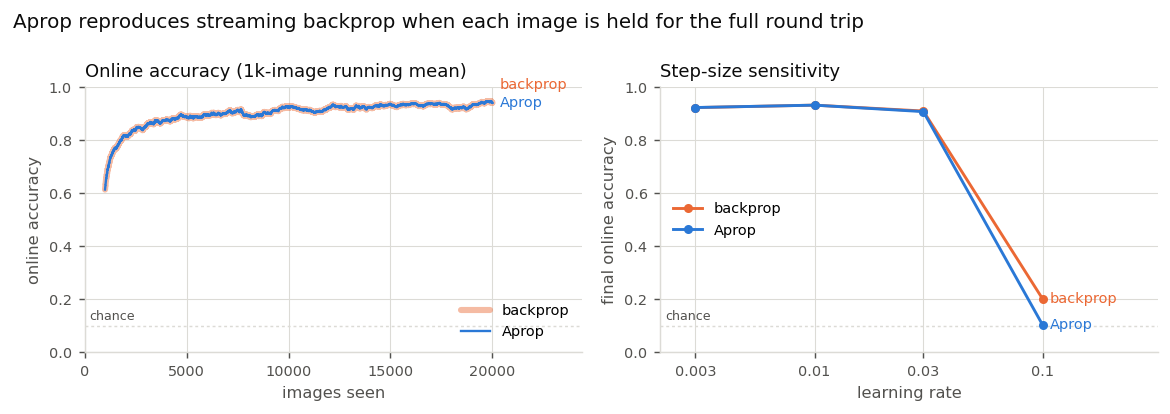

In [10]:
L1 = 3
res_a, lr_a, curve_a = sweep_lr(lambda lr: aprop(L1, hold_steps=2 * L1, lr=lr, n_images=N_MAIN))
res_b, lr_b, curve_b = sweep_lr(lambda lr: bp(L1, lr, n_images=N_MAIN))
print(f'aprop best lr={lr_a}  final acc={final_acc(res_a):.3f}')
print(f'bp    best lr={lr_b}  final acc={final_acc(res_b):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))

ax = axes[0]
xb, yb = curve(res_b, 1000)
xa, ya = curve(res_a, 1000)
ax.plot(xb, yb, color=C_BP, lw=3.4, alpha=0.45, label='backprop', solid_capstyle='round')
ax.plot(xa, ya, color=C_APROP, lw=1.3, label='Aprop')
acc_axis(ax)
ax.set_xlabel('images seen')
ax.set_xlim(0, N_MAIN * 1.22)
ax.set_title('Online accuracy (1k-image running mean)')
label_ends(ax, [(xa, ya, 'Aprop', C_APROP), (xb, yb, 'backprop', C_BP)])
ax.legend(loc='lower right')

ax = axes[1]
for curve_dict, color, name in [(curve_b, C_BP, 'backprop'), (curve_a, C_APROP, 'Aprop')]:
    lrs = sorted(curve_dict)
    ax.plot(lrs, [curve_dict[k] for k in lrs], color=color, marker='o', ms=4, label=name)
acc_axis(ax, 'final online accuracy')
ax.set_xscale('log')
ax.set_xlim(min(LRS) * 0.7, max(LRS) * 3.2)
log_ticks(ax, list(LRS))
ax.set_xlabel('learning rate')
ax.set_title('Step-size sensitivity')
label_ends(ax, [(sorted(curve_a), [curve_a[k] for k in sorted(curve_a)], 'Aprop', C_APROP),
                (sorted(curve_b), [curve_b[k] for k in sorted(curve_b)], 'backprop', C_BP)])
ax.legend(loc='center left')

fig.suptitle('Aprop reproduces streaming backprop when each image is held for the full round trip',
             x=0.005, ha='left', fontsize=11, color=INK)
fig.tight_layout()
plt.show()

## Experiment 2 — how long each image is shown

`hold_steps` is the number of event ticks an image stays on the input wire. Two update clocks:

- **aligned** — $\mathcal{T}_l$ fires once per presentation, at the tick where layer $l$'s traces are
  consistent (tick $\tau_k + 2L-1-l$). One update per image.
- **free-running** — $\mathcal{T}_l$ fires every tick, so a long hold means `hold_steps` updates per
  image. This is the more literal reading of Algorithm 1, and it needs a smaller step size.

The prediction is *not* whether more ticks help by giving more updates — it is that below
$2L-1 = 5$ ticks the activation traces and the error traces belong to *different images*, so the
outer product $\hat\delta_l\hat a_{l-1}^\top$ stops being a gradient at all.

hold= 1  aligned 0.122 @ lr=0.003  free 0.122 @ lr=0.003


hold= 2  aligned 0.296 @ lr=0.003  free 0.253 @ lr=0.003


hold= 4  aligned 0.427 @ lr=0.003  free 0.502 @ lr=0.003


hold= 8  aligned 0.915 @ lr=0.01   free 0.870 @ lr=0.0003


hold=16  aligned 0.915 @ lr=0.01   free 0.892 @ lr=0.0003


backprop reference 0.915 @ lr=0.01


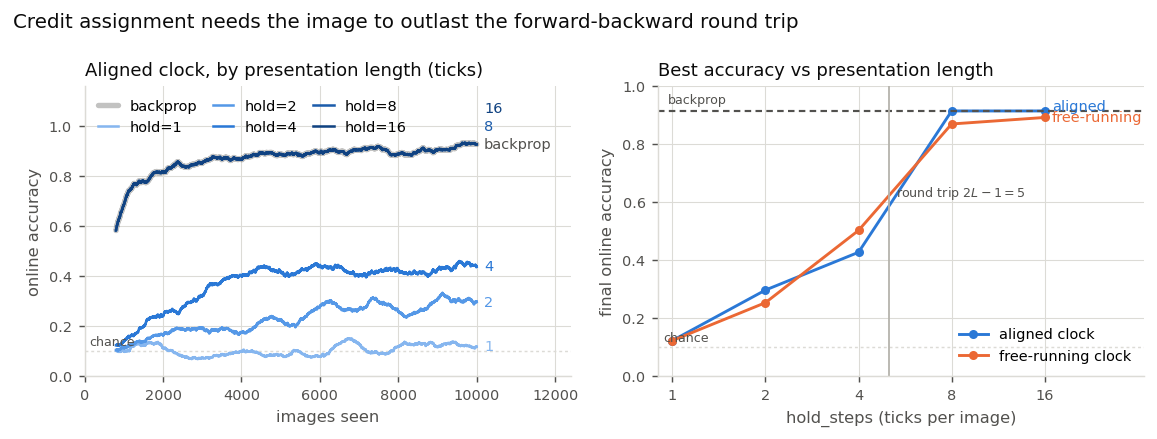

In [11]:
HOLDS = [1, 2, 4, 8, 16]
LRS_FREE = (3e-4, 1e-3, 3e-3, 1e-2, 3e-2)
L2 = 3

hold_aligned, hold_free = {}, {}
for h in HOLDS:
    hold_aligned[h] = sweep_lr(lambda lr, h=h: aprop(L2, h, lr, clock='aligned'))
    hold_free[h] = sweep_lr(lambda lr, h=h: aprop(L2, h, lr, clock='free'), lrs=LRS_FREE)
    print(f'hold={h:2d}  aligned {final_acc(hold_aligned[h][0]):.3f} @ lr={hold_aligned[h][1]:<6} '
          f'free {final_acc(hold_free[h][0]):.3f} @ lr={hold_free[h][1]}')

bp_ref = sweep_lr(lambda lr: bp(L2, lr))
print(f'backprop reference {final_acc(bp_ref[0]):.3f} @ lr={bp_ref[1]}')

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))

ax = axes[0]
xb, yb = curve(bp_ref[0])
ax.plot(xb, yb, color=INK2, lw=3.0, alpha=0.35, label='backprop', solid_capstyle='round')
labels = [(xb, yb, 'backprop', INK2)]
for h, color in zip(HOLDS, RAMP):
    x, y = curve(hold_aligned[h][0])
    ax.plot(x, y, color=color, lw=1.4, label=f'hold={h}')
    labels.append((x, y, str(h), color))
acc_axis(ax, ymax=1.16)
ax.set_xlabel('images seen')
ax.set_xlim(0, N_SWEEP * 1.24)
ax.set_title('Aligned clock, by presentation length (ticks)')
label_ends(ax, labels)
ax.legend(loc='upper left', ncols=3, columnspacing=1.1, handlelength=1.4)

ax = axes[1]
labels = []
for data, color, name in [(hold_aligned, C_APROP, 'aligned'), (hold_free, C_BP, 'free-running')]:
    y = [final_acc(data[h][0]) for h in HOLDS]
    ax.plot(HOLDS, y, color=color, marker='o', ms=4, label=f'{name} clock')
    labels.append((HOLDS, y, name, color))
ax.axhline(final_acc(bp_ref[0]), color=INK2, lw=1.2, ls=(0, (3, 2)))
ax.annotate('backprop', xy=(0.02, final_acc(bp_ref[0])), xycoords=('axes fraction', 'data'),
            xytext=(0, 4), textcoords='offset points', color=INK2, fontsize=7)
ax.axvline(2 * L2 - 1, color=RULE, lw=1.0)
ax.annotate(f'round trip $2L-1={2 * L2 - 1}$', xy=(2 * L2 - 1, 0.62), xytext=(4, 0),
            textcoords='offset points', color=INK2, fontsize=7)
acc_axis(ax, 'final online accuracy')
ax.set_xscale('log', base=2)
log_ticks(ax, HOLDS)
ax.set_xlim(0.9, HOLDS[-1] * 2.1)
ax.set_xlabel('hold_steps (ticks per image)')
ax.set_title('Best accuracy vs presentation length')
label_ends(ax, labels)
ax.legend(loc='lower right')

fig.suptitle('Credit assignment needs the image to outlast the forward-backward round trip',
             x=0.005, ha='left', fontsize=11, color=INK)
fig.tight_layout()
plt.show()

## Experiment 3 — deeper networks

Depth enters twice. It makes the optimisation problem harder for *any* streaming method (the
backprop baseline pays that too), and it stretches the round trip to $2L-1$ ticks, which is a cost
unique to Aprop. Separating the two: run each depth with a **fixed** budget of 8 ticks per image,
and with a budget **scaled** to $2L$ ticks per image.

depth=2 (2L-1= 3)  hold=8 0.914   hold=2L 0.914   bp 0.914


depth=3 (2L-1= 5)  hold=8 0.915   hold=2L 0.915   bp 0.915


depth=4 (2L-1= 7)  hold=8 0.910   hold=2L 0.910   bp 0.910


depth=6 (2L-1=11)  hold=8 0.294   hold=2L 0.899   bp 0.895


depth=8 (2L-1=15)  hold=8 0.189   hold=2L 0.874   bp 0.888


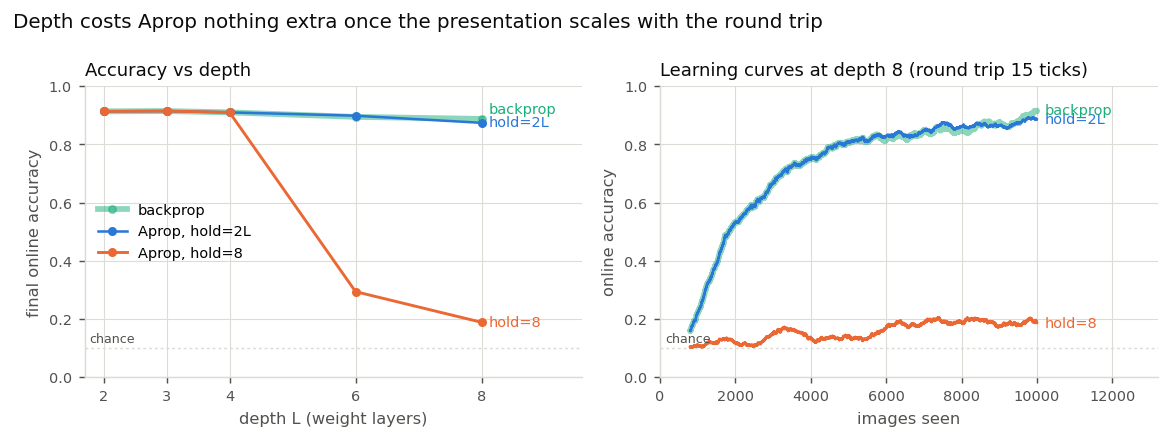

In [12]:
DEPTHS = [2, 3, 4, 6, 8]
FIXED_HOLD = 8

depth_fixed, depth_scaled, depth_bp = {}, {}, {}
for nl in DEPTHS:
    depth_fixed[nl] = sweep_lr(lambda lr, nl=nl: aprop(nl, FIXED_HOLD, lr))
    depth_scaled[nl] = sweep_lr(lambda lr, nl=nl: aprop(nl, 2 * nl, lr))
    depth_bp[nl] = sweep_lr(lambda lr, nl=nl: bp(nl, lr))
    print(f'depth={nl} (2L-1={2 * nl - 1:2d})  hold=8 {final_acc(depth_fixed[nl][0]):.3f}   '
          f'hold=2L {final_acc(depth_scaled[nl][0]):.3f}   bp {final_acc(depth_bp[nl][0]):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
series = [(depth_bp, C_THIRD, 'backprop', 3.2, 0.5),
          (depth_scaled, C_APROP, 'Aprop, hold=2L', 1.4, 1.0),
          (depth_fixed, C_BP, f'Aprop, hold={FIXED_HOLD}', 1.6, 1.0)]

ax = axes[0]
labels = []
for data, color, name, lw, alpha in series:
    y = [final_acc(data[nl][0]) for nl in DEPTHS]
    ax.plot(DEPTHS, y, color=color, lw=lw, alpha=alpha, marker='o', ms=4, label=name)
    labels.append((DEPTHS, y, name.replace('Aprop, ', ''), color))
acc_axis(ax, 'final online accuracy')
ax.set_xticks(DEPTHS)
ax.set_xlim(DEPTHS[0] - 0.3, DEPTHS[-1] + 1.6)
ax.set_xlabel('depth L (weight layers)')
ax.set_title('Accuracy vs depth')
label_ends(ax, labels)
ax.legend(loc='center left')

ax = axes[1]
deep = DEPTHS[-1]
labels = []
for data, color, name, lw, alpha in series:
    x, y = curve(data[deep][0])
    ax.plot(x, y, color=color, lw=lw, alpha=alpha, solid_capstyle='round')
    labels.append((x, y, name.replace('Aprop, ', ''), color))
acc_axis(ax)
ax.set_xlabel('images seen')
ax.set_xlim(0, N_SWEEP * 1.32)
ax.set_title(f'Learning curves at depth {deep} (round trip {2 * deep - 1} ticks)')
label_ends(ax, labels)

fig.suptitle('Depth costs Aprop nothing extra once the presentation scales with the round trip',
             x=0.005, ha='left', fontsize=11, color=INK)
fig.tight_layout()
plt.show()

## Experiment 4 — trace rates $\beta$

Everything above used $\beta = 1$, i.e. traces that just latch the incoming message. Smoothing
($\beta < 1$) means a trace needs $\approx 1/\beta$ events per layer to settle, so it lengthens the
effective round trip: it should be harmless when the image is held long enough and the target is
delayed past the settling time, and destructive when it is not. The output error trace $\hat\delta_L$
is a separate case — it only moves on target events, one per image, so $\beta_\delta < 1$ averages
the errors of *different* images no matter how long the hold is.

beta=0.1   msg/tight 0.114   msg/slow 0.132   err-trace 0.172
beta=0.25  msg/tight 0.097   msg/slow 0.871   err-trace 0.350
beta=0.5   msg/tight 0.094   msg/slow 0.868   err-trace 0.712
beta=1.0   msg/tight 0.868   msg/slow 0.868   err-trace 0.868
beta=0.1 with hold=128, delay=48: 0.854


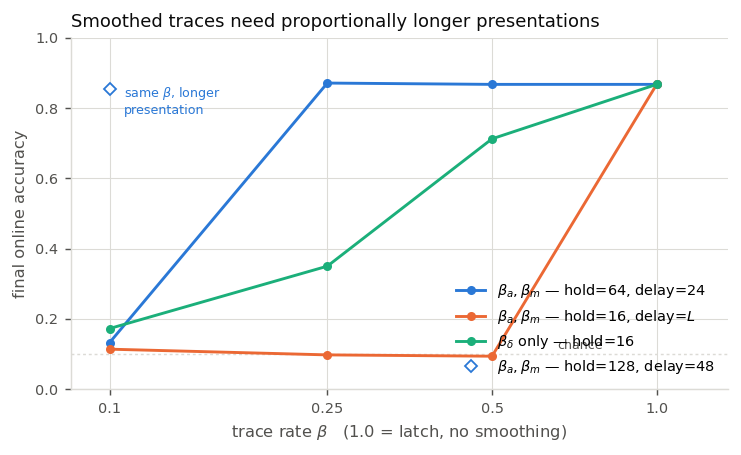

In [13]:
BETAS = [0.1, 0.25, 0.5, 1.0]
LRS_B = (3e-3, 1e-2, 3e-2)
N_BETA = 4_000
L4 = 3

# message traces smoothed, in a tight timing budget vs. a generous one
beta_tight = {b: sweep_lr(lambda lr, b=b: aprop(L4, 16, lr, n_images=N_BETA, beta_a=b, beta_m=b),
                          lrs=LRS_B) for b in BETAS}
beta_slow = {b: sweep_lr(lambda lr, b=b: aprop(L4, 64, lr, n_images=N_BETA, target_delay=24,
                                               late=True, beta_a=b, beta_m=b), lrs=LRS_B)
             for b in BETAS}
# output error trace smoothed instead (mixes targets across images)
beta_err = {b: sweep_lr(lambda lr, b=b: aprop(L4, 16, lr, n_images=N_BETA, beta_d=b), lrs=LRS_B)
            for b in BETAS}
# beta = 0.1 needs ~L/beta ticks to settle; hold=64/delay=24 is still too short for it
beta01_long = sweep_lr(lambda lr: aprop(L4, 128, lr, n_images=N_BETA, target_delay=48, late=True,
                                        beta_a=0.1, beta_m=0.1), lrs=LRS_B)

for b in BETAS:
    print(f'beta={b:<5} msg/tight {final_acc(beta_tight[b][0]):.3f}   '
          f'msg/slow {final_acc(beta_slow[b][0]):.3f}   err-trace {final_acc(beta_err[b][0]):.3f}')
print(f'beta=0.1 with hold=128, delay=48: {final_acc(beta01_long[0]):.3f}')

fig, ax = plt.subplots(figsize=(5.8, 3.6))
for data, color, name in [
        (beta_slow, C_APROP, r'$\beta_a,\beta_m$ — hold=64, delay=24'),
        (beta_tight, C_BP, r'$\beta_a,\beta_m$ — hold=16, delay=$L$'),
        (beta_err, C_THIRD, r'$\beta_\delta$ only — hold=16')]:
    ax.plot(BETAS, [final_acc(data[b][0]) for b in BETAS], color=color, marker='o', ms=4, label=name)
ax.plot([0.1], [final_acc(beta01_long[0])], color=C_APROP, marker='D', ms=5, ls='none',
        mfc='white', label=r'$\beta_a,\beta_m$ — hold=128, delay=48')
ax.annotate('same $\\beta$, longer\npresentation', xy=(0.1, final_acc(beta01_long[0])),
            xytext=(8, -14), textcoords='offset points', color=C_APROP, fontsize=7)
acc_axis(ax, 'final online accuracy', chance_x=0.74)
ax.set_xscale('log')
log_ticks(ax, BETAS)
ax.set_xlim(0.085, 1.35)
ax.set_xlabel(r'trace rate $\beta$   (1.0 = latch, no smoothing)')
ax.set_title('Smoothed traces need proportionally longer presentations', fontsize=10)
ax.legend(loc='lower right')
fig.tight_layout()
plt.show()

## Summary

Numbers are final online accuracy (mean over the last 20% of the stream), each configuration at its
own best learning rate. 784-64-…-10 ReLU MLPs, i.i.d. MNIST stream, one pass, no batching.

**1. It works, and at the limit it *is* backprop.** With $\beta = 1$, `hold_steps` $\ge 2L$ and the
update clock aligned, Aprop matches the streaming-backprop baseline to three decimals at every
depth tested (0.933 vs 0.933 at $L=3$; 0.874 vs 0.888 at $L=8$). That is not a coincidence to be
explained away — the settled traces *are* the forward activations and the backprop deltas, which the
gradient check at the top confirms to 6e-8. The interest in the algorithm is therefore not in what it
computes at that limit but in what it costs to get there and how it fails away from it.

**2. Presentation time is the binding constraint, and the threshold is the round trip $2L-1$.**
At $L=3$ (round trip 5 ticks): hold=1 → 0.12 (chance), hold=2 → 0.30, hold=4 → 0.43,
hold=8 → 0.915 = backprop. Below the round trip, the activation trace at layer $l$ holds a *newer*
image than the error trace does, so $\hat\delta_l\hat a_{l-1}^\top$ is an outer product of two
unrelated vectors — not a noisy gradient, just noise. No learning rate rescues it.

**3. Depth is only expensive because it lengthens the round trip.** At a fixed 8 ticks per image,
accuracy holds up to $L=4$ (0.910) and then falls off a cliff exactly where $2L-1$ passes the hold:
$L=6$ → 0.294, $L=8$ → 0.189. Scale the presentation to $2L$ ticks and every depth matches
backprop again (0.899 / 0.874 vs 0.895 / 0.888). So the price of depth is **ticks per sample, not
accuracy** — the number of event ticks a sample must persist grows linearly in $L$, which is the real
cost to weigh against the fact that no layer ever waits for a global pass.

**4. Which clock $\mathcal{T}_l$ uses trades step size for latency tolerance.** Firing every tick
(the literal reading of line 19) does `hold_steps` updates per image, most of them on stale traces;
it lands close to the aligned clock but needs a ~30× smaller learning rate (0.0003 vs 0.01 at
hold=16) and never quite reaches the baseline (0.892 vs 0.915).

**5. Trace smoothing costs presentation time, and $\beta_\delta$ is special.** Smoothing the message
traces is harmless *if* the timing budget grows with $1/\beta$: $\beta=0.25$ scores 0.10 at
hold=16 but 0.871 at hold=64, and $\beta=0.1$ needs hold=128 to reach 0.85. The output error trace
is different in kind — it only advances on target events, one per image, so $\beta_\delta < 1$ blends
the errors of *different* images regardless of the hold (0.35 at $\beta_\delta = 0.25$, 0.71 at 0.5,
0.87 at 1.0). If a trace rate should be tuned separately from the others, it is that one.

**Caveats.** Single seed per configuration, i.i.d. stream (so successive inputs are maximally
dissimilar — a temporally correlated stream should be markedly more forgiving of a short hold, which
is the obvious next experiment), softmax cross-entropy rather than the regression loss the algorithm
is written for, and all message clocks left at period 1 so the only asynchrony explored is in
$\mathcal{T}_l$. `fwd_period`/`bwd_period` are implemented and untested — layers messaging at
genuinely different rates is where the interesting failure modes probably live.